# Week 2
on week 2 my goal is to code a Bayesian Optimization for functions with multiple features



In [1]:

import numpy as np
import matplotlib.pyplot as plt
import math
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from scipy.stats import qmc



# Function 3
This function has 4 dimensions.

### Data preparation

Here we prepare the initial data provided

In [2]:
input = np.load('./../../data/initial_data/function_4/initial_inputs.npy')
output = np.load('./../../data/initial_data/function_4/initial_outputs.npy')
print(input)
print(output)
#print(input.shape)
#print(input.shape[1])
func_dimensions = input.shape[1]
print('this function has ', func_dimensions, ' dimensions')

[[0.89698105 0.72562797 0.17540431 0.70169437]
 [0.8893564  0.49958786 0.53926886 0.50878344]
 [0.25094624 0.03369313 0.14538002 0.49493242]
 [0.34696206 0.0062504  0.76056361 0.61302356]
 [0.12487118 0.12977019 0.38440048 0.2870761 ]
 [0.80130271 0.50023109 0.70664456 0.19510284]
 [0.24770826 0.06044543 0.04218635 0.44132425]
 [0.74670224 0.7570915  0.36935306 0.20656628]
 [0.40066503 0.07257425 0.88676825 0.24384229]
 [0.6260706  0.58675126 0.43880578 0.77885769]
 [0.95713529 0.59764438 0.76611385 0.77620991]
 [0.73281243 0.14524998 0.47681272 0.13336573]
 [0.65511548 0.07239183 0.68715175 0.08151656]
 [0.21973443 0.83203134 0.48286416 0.08256923]
 [0.48859419 0.2119651  0.93917791 0.37619173]
 [0.16713049 0.87655456 0.21723954 0.95980098]
 [0.21691119 0.16608583 0.24137226 0.77006248]
 [0.38748784 0.80453226 0.75179548 0.72382744]
 [0.98562189 0.66693268 0.15678328 0.8565348 ]
 [0.03782483 0.66485335 0.16198218 0.25392378]
 [0.68348638 0.9027701  0.33541983 0.99948256]
 [0.17034731 

Here we add the data provided with the weekly queries

In [3]:
inputWeek1 = np.array([0.5, 0.5, 0.5, 0.5])
outputWeek1 = -3.985750969810286

input = np.append(input, [[inputWeek1[0], inputWeek1[1], inputWeek1[2], inputWeek1[3]]], axis=0)
output = np.append(output, outputWeek1)

print(input)
print(output)

[[0.89698105 0.72562797 0.17540431 0.70169437]
 [0.8893564  0.49958786 0.53926886 0.50878344]
 [0.25094624 0.03369313 0.14538002 0.49493242]
 [0.34696206 0.0062504  0.76056361 0.61302356]
 [0.12487118 0.12977019 0.38440048 0.2870761 ]
 [0.80130271 0.50023109 0.70664456 0.19510284]
 [0.24770826 0.06044543 0.04218635 0.44132425]
 [0.74670224 0.7570915  0.36935306 0.20656628]
 [0.40066503 0.07257425 0.88676825 0.24384229]
 [0.6260706  0.58675126 0.43880578 0.77885769]
 [0.95713529 0.59764438 0.76611385 0.77620991]
 [0.73281243 0.14524998 0.47681272 0.13336573]
 [0.65511548 0.07239183 0.68715175 0.08151656]
 [0.21973443 0.83203134 0.48286416 0.08256923]
 [0.48859419 0.2119651  0.93917791 0.37619173]
 [0.16713049 0.87655456 0.21723954 0.95980098]
 [0.21691119 0.16608583 0.24137226 0.77006248]
 [0.38748784 0.80453226 0.75179548 0.72382744]
 [0.98562189 0.66693268 0.15678328 0.8565348 ]
 [0.03782483 0.66485335 0.16198218 0.25392378]
 [0.68348638 0.9027701  0.33541983 0.99948256]
 [0.17034731 

# Bayesian Optimisation approach
We approach the study of this function with the Bayesian Optimisation
using and adaptation of the UCB acquisition function from required assignment 12.1

# Preparation of the exploration space
Here we prepare the exploration space of the function<br>
The values are increments of 0.01 bounded between 0 and 1 (included) => 101 values for each dimension of the space<br>
dimension of the current function is stored in <b>func_dimensions</b>

In [5]:
#Initialise query lists and maximum observations
X, Y = input, output

#Initialise grid for plots
vector_values = np.linspace(0, 1, 101)# 101 values from 0 to 1
#print(vector_values)
#x_grid = np.empty((1,func_dimensions))
#print(x_grid)

#merda originale
#for i in vector_values:
#    for j in vector_values:
#        for k in vector_values:
#            x_grid = np.append(x_grid, [[i, j, k]], axis=0)

# Versione generalizzata per qualsiasi numero di dimensioni
#grids = np.meshgrid(*([vector_values] * func_dimensions), indexing='ij')
#x_grid = np.column_stack([grid.ravel() for grid in grids])

# --- METODO 1: Latin Hypercube Sampling (LHS) ---
# Ottimo bilanciamento tra copertura uniforme e numero di campioni
n_samples = 100000000  # Numero di punti desiderati
sampler_lhs = qmc.LatinHypercube(d=func_dimensions, seed=42)
x_grid = sampler_lhs.random(n=n_samples)
#print(f"LHS shape: {x_grid_lhs.shape}")

#x_grid = np.delete(x_grid, 0, axis=0)
#print(x_grid)
print(x_grid.shape)


(100000000, 4)


# Bayesian Optimisation with UCB applied

In [ ]:
rbf_lengthscale = [0.1, 0.1, 0.1, 0.1]
real_noise_std = 1e-10
noise_assumption = 1e-10

#Define kernel of GP
kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds='fixed')

model = GaussianProcessRegressor(kernel = kernel)
#Fit the model
model.fit(np.array(X), np.array(Y).reshape(-1, 1))


#Calculate the mean and standard deviation and make them one-dimensional for plotting
post_mean, post_std = model.predict(x_grid, return_std=True)

#Acquisition function parameter
beta = 1.96
#beta = 0.5

acquisition_function = post_mean + beta * post_std

grid = x_grid.squeeze()
obs = grid[np.argmax(acquisition_function)] #Else use the acquisition function

print('Next observation: ', obs)
#print (obs)


# Plottings

In [13]:
post_mean, post_std = post_mean.squeeze(), post_std.squeeze()
print(post_mean)
print(len(post_mean))
print(post_std)
print(len(post_std))


[-3.45352486e-06 -4.41064187e-06 -5.57990660e-06 ... -4.01014286e-06
 -2.63967615e-06 -1.72027766e-06]
1030301
[1. 1. 1. ... 1. 1. 1.]
1030301


In [14]:
max_obs = 0
max_obs = max(max_obs, max(acquisition_function))

#Initialise plots
fig, ax = plt.subplots(figsize = (15, 7))
#Set the x and y limits, labels and dynamic title
ax.set_xlim(0, 1)
ax.set_ylim(min(post_mean) - 0.001, max(post_mean) + 0.001)
ax.set_ylabel('f(x)')
ax.set_xlabel('x normalized inputs')
#Plot queries
#ax.scatter(X, Y, c = 'r', marker='x', s = 100)
#ax.scatter(x_grid.squeeze(), post_mean, c = 'r', marker='.', s = 100)

#Plot the mean and standard deviation
ax.plot(x_grid, post_mean,  label = 'post_mean')
#ax.plot(x_grid, post_std,  label = 'post_std')
#ax.plot(x_grid.squeeze(), post_mean, label = 'GP Posterior Mean')
#ax.fill_between(x_grid.squeeze(), post_mean - beta*post_std, post_mean + beta*post_std, alpha = 0.2, label = str(beta) + ' Standard Deviations')
ax.legend()
#plt.show()



/Users/leonardo/leonardo/capstone/CapstoneProjectImperial/.venv/lib/python3.14/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/Users/leonardo/leonardo/capstone/CapstoneProjectImperial/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


Error in callback <function flush_figures at 0x10fadde80> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

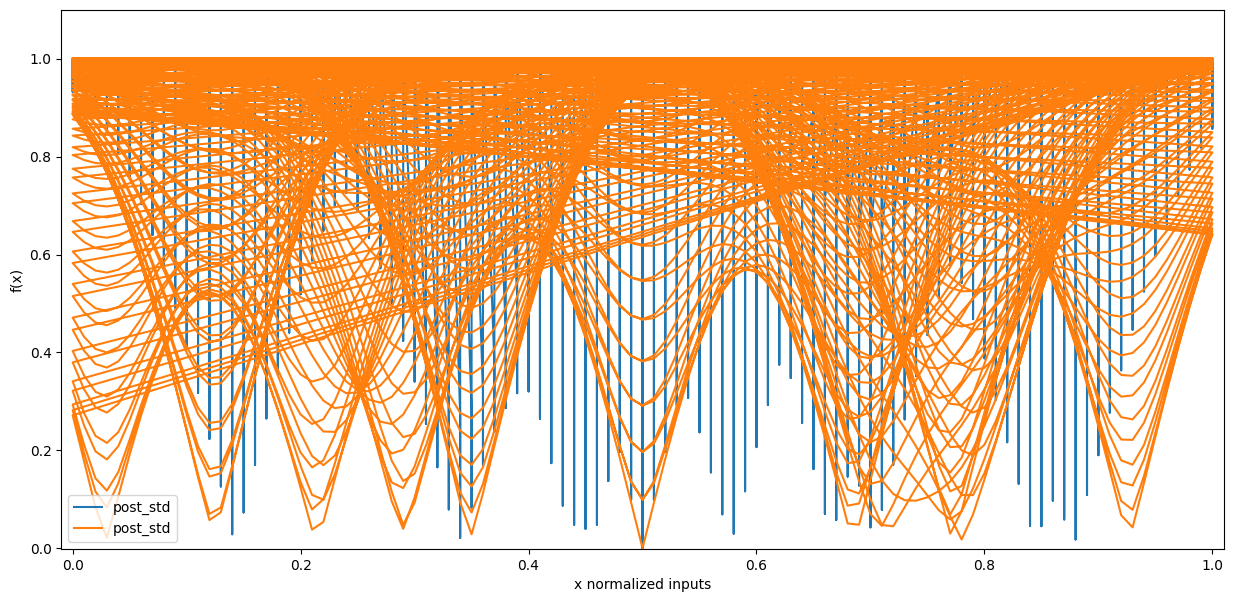

In [39]:
max_obs = 0
max_obs = max(max_obs, max(acquisition_function))

#Initialise plots
fig, ax = plt.subplots(figsize = (15, 7))
#Set the x and y limits, labels and dynamic title
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(min(post_std) - 0.001, max(post_std) + 0.1)
ax.set_ylabel('f(x)')
ax.set_xlabel('x normalized inputs')
#Plot queries
#ax.scatter(X, Y, c = 'r', marker='x', s = 100)
#ax.scatter(x_grid.squeeze(), post_mean, c = 'r', marker='.', s = 100)

#Plot the mean and standard deviation
#ax.plot(x_grid, post_mean,  label = 'post_mean')
ax.plot(x_grid, post_std,  label = 'post_std')
#ax.plot(x_grid.squeeze(), post_mean, label = 'GP Posterior Mean')
#ax.fill_between(x_grid.squeeze(), post_mean - beta*post_std, post_mean + beta*post_std, alpha = 0.2, label = str(beta) + ' Standard Deviations')
ax.legend()
#plt.show()



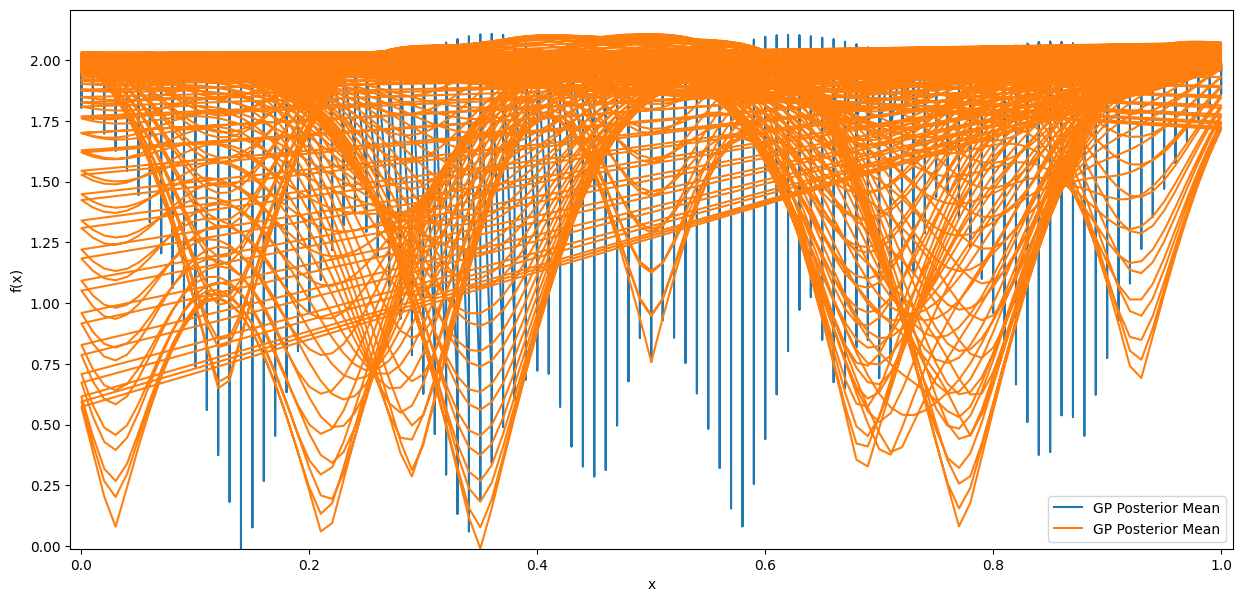

In [40]:
max_obs = 0
max_obs = max(max_obs, max(acquisition_function))

#Initialise plots
fig, ax = plt.subplots(figsize = (15, 7))
#Set the x and y limits, labels and dynamic title
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(min(acquisition_function) - 0.001, max(acquisition_function) + 0.1)
ax.set_ylabel('f(x)')
ax.set_xlabel('x')
#Plot queries
#ax.scatter(X, Y, c = 'r', marker='x', s = 100)
#ax.scatter(x_grid.squeeze(), post_mean, c = 'r', marker='.', s = 100)

#Plot the mean and standard deviation
#ax.plot(x_grid, post_mean,  label = 'post_mean')
ax.plot(x_grid, acquisition_function,  label = 'GP Posterior Mean')
#ax.plot(x_grid.squeeze(), post_mean, label = 'GP Posterior Mean')
#ax.fill_between(x_grid.squeeze(), post_mean - beta*post_std, post_mean + beta*post_std, alpha = 0.2, label = str(beta) + ' Standard Deviations')
ax.legend()
#plt.show()

